# S&DS 617 Advances in Large Language Models: Theory and Applications: Assignment 3

**Deadline**

Assignment 3 is due Monday, April 7th at 1:30pm.

**Submission**

Submit your assignment as a .pdf on Gradescope. On Gradescope, there are 2 assignments, one where you will submit a pdf file and one where you will submit the corresponding .ipynb that generated it.
Note: The problems in each homework assignment are numbered. When submitting the pdf on Gradescope, please select the correct pages that correspond to each problem.

To produce the .pdf, do the following to preserve the cell structure of the notebook:
- Go to "File" at the top-left of your Jupyter Notebook
- Under "Download as", select "HTML (.html)"
- After the .html has downloaded, open it and then select "File" and "Print"
- From the print window, select the option to save as a .pdf

In this assignment, we will fine-tune BERT using LoRA on the Yelp reviews dataset to predict whether a review is positive or negative. Some starter code has been provided to you below.

### Load data

In [ ]:
!pip install datasets requests torch pandas peft transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import datasets
import requests, tarfile, os
import torch
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import roc_auc_score

In [ ]:
# URL of the Yelp reviews dataset
_DOWNLOAD_URL = "https://s3.amazonaws.com/fast-ai-nlp/yelp_review_polarity_csv.tgz"

# Function to download and extract the dataset
def download_and_extract_dataset(url):
    # Download the dataset
    local_file = "yelp_review_polarity_csv.tgz"
    response = requests.get(url)
    open(local_file, 'wb').write(response.content)

    # Extract the dataset
    tar = tarfile.open(local_file, "r:gz")
    tar.extractall()
    tar.close()

# Function to load the dataset into pandas DataFrame
def load_dataset():
    # Download and extract if dataset directory doesn't exist
    if not os.path.exists("yelp_review_polarity_csv"):
        download_and_extract_dataset(_DOWNLOAD_URL)

    # Load train and test datasets
    train_data = pd.read_csv("yelp_review_polarity_csv/train.csv", header=None, names=["label", "text"])
    test_data = pd.read_csv("yelp_review_polarity_csv/test.csv", header=None, names=["label", "text"])

    # Subsample down
    train_data = train_data.sample(n=5000, random_state=11)
    test_data = test_data.sample(n=1000, random_state=94)

    # Adjust labels to be zero-based if necessary
    train_data['label'] -= 1
    test_data['label'] -= 1

    return train_data, test_data

# Load the data
train_data, test_data = load_dataset()

# Display the first few rows of the train and test sets
print(train_data.head())
print(test_data.head())

        label                                               text
478660      0  Not a good place. WAY over proceed for what it...
330978      1  They have the best cocktails! They are all mad...
473311      1  Great pizza. The owner use to work for metro s...
320559      1  Wow. What a great show!\n\nThere are several d...
526693      0  Me and my boyfriend started coming here after ...
       label                                               text
9423       1  Dirty martinis with blue cheese olives!!!!!!!!...
29439      0  My husband had gone to a different location th...
7064       1  Very tasty food! The lady's offer prompt and s...
18986      0  Very so so burgers. Best to head elsewhere for...
16556      0  As a New Yorker, I was looking forward to tryi...


In [ ]:
train_data.iloc[0]['text']

'Not a good place. WAY over proceed for what it is, just a COMPLETE waste of time. Just go ANYWHERE else'

In [ ]:
# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Dataset class for Yelp Polarity Reviews
class YelpPolarityReviewDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Check if the index is valid
        if idx < 0 or idx >= len(self.data):
            raise IndexError(f"Index {idx} is out of bounds for dataset with length {len(self.data)}")
        review = self.data.iloc[idx]['text']
        label = self.data.iloc[idx]['label']
        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
max_len = 128
train_dataset = YelpPolarityReviewDataset(train_data, tokenizer, max_len)
test_dataset = YelpPolarityReviewDataset(test_data, tokenizer, max_len)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=1, lora_alpha=1, lora_dropout=0.1
)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model = get_peft_model(model, lora_config)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Function to compute AUC for binary classification
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Convert to probabilities using sigmoid (since it's binary classification)
    probs = np.exp(logits) / (1 + np.exp(logits))
    # For binary classification, use the probabilities of the positive class (assumed to be at index 1)
    probs = probs[:, 1]
    # Calculate AUC
    auc = roc_auc_score(labels, probs)
    return {"auc": auc}

# Training arguments
training_args = TrainingArguments(
    output_dir="test_trainer",
    evaluation_strategy="epoch",
    num_train_epochs=15,
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Start training
trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: maddie02468 (maddie02468-yale-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Auc
1,0.667800,0.547972,0.843289
2,0.484900,0.337220,0.934095
3,0.343400,0.305284,0.949718
4,0.305700,0.309032,0.954111
5,0.297900,0.295172,0.956607
6,0.279100,0.287776,0.958920
7,0.284500,0.292046,0.960244
8,0.279000,0.290013,0.961276
9,0.267100,0.285657,0.961765
10,0.282900,0.295671,0.962661


TrainOutput(global_step=9375, training_loss=0.3144211450195312, metrics={'train_runtime': 1546.0038, 'train_samples_per_second': 48.512, 'train_steps_per_second': 6.064, 'total_flos': 4935544243200000.0, 'train_loss': 0.3144211450195312, 'epoch': 15.0})

## Problem 1: Comparison of Trainable Parameters
Compare the total number of trainable parameters between the standard fine-tuning approach and the Low-Rank Adaptation (LoRA) method. Detail how LoRA alters the model’s parameter complexity compared to traditional fine-tuning. Discuss the implications of these changes on the model's training efficiency, accuracy, and computational demand. Consider including a discussion on parameter sharing and model capacity in your answer. Under what scenarios might one method be preferred over the other, considering factors such as available computational resources, the complexity of the task, and dataset size?

*When comparing standard fine-tuning and Low-Rank Adaptation (LoRA) for large language models like BERT, the most significant difference lies in the number of trainable parameters and the computational demand during training. In traditional fine-tuning, all of BERT’s approximately 110 million parameters are updated. This includes the embedding layer, all 12 transformer layers, and the classification head. As a result, fine-tuning is computationally intensive, requiring significant memory and processing power, especially when training on GPUs or limited hardware.*

*LoRA, by contrast, introduces small, trainable low-rank matrices into specific layers—typically the attention layers—while keeping the original model weights frozen. Instead of updating the full parameter set, LoRA only adjusts these new matrices and the classification head. The additional parameters introduced by LoRA are minimal compared to full fine-tuning.*

*For instance, applying LoRA with a rank of one (r=1) to all attention layers in BERT would introduce roughly 14 million trainable parameters. However, LoRA is often applied to only a subset of layers, reducing this number further to around 5 to 15 million total trainable parameters, depending on the configuration. This reduction dramatically lowers memory usage and speeds up training.*

*From a capacity and generalization perspective, LoRA’s design allows the model to retain the general knowledge learned during pretraining since the base model weights remain untouched. Instead, LoRA layers adapt the model to the specific downstream task. This approach helps mitigate issues like catastrophic forgetting while still allowing for effective task-specific learning. However, because LoRA’s adaptation capacity is limited by the chosen rank parameter, very complex or domain-specific tasks with large datasets might benefit more from full fine-tuning, where the model’s entire capacity can be leveraged.*

*LoRA is particularly advantageous in scenarios where computational resources are limited, such as training on personal laptops or serving models on edge devices. It is also ideal for tasks with smaller datasets, where fewer trainable parameters help reduce overfitting. Additionally, LoRA’s modular nature enables efficient storage and deployment since only the small adapter layers need to be saved or swapped for different tasks. On the other hand, full fine-tuning may still be preferable when working with very large datasets or tasks that are significantly different from the model’s pretraining domain, such as biomedical text or specialized legal documents.*

*For a project like sentiment classification on Yelp reviews, where the dataset is moderate in size and the task aligns closely with what BERT was pretrained on, LoRA strikes an excellent balance. It offers substantial computational savings with little to no drop in accuracy, making it an efficient and practical choice, especially for rapid experimentation or deployment on limited hardware.*

## Problem 2: Hyperparameter Experimentation with LoRA
In your experimentation with the LoRA configuration, document the process and present your findings in a structured manner. Describe the specific LoRA hyperparameters you adjusted, including the rank (`r`) and the learning rate scale (`lora_alpha`). Test a range of values for each and analyze how changing these hyperparameters affects the model's performance in terms of training convergence speed and final model accuracy. Provide graphs or tables to support your findings

In [ ]:
#run 1 is the above code shown in the starter with r as 1 and lora_alpha as 1
#this is run 2 with r as 4 and lora_alpha as 16

In [ ]:
# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Dataset class for Yelp Polarity Reviews
class YelpPolarityReviewDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Check if the index is valid
        if idx < 0 or idx >= len(self.data):
            raise IndexError(f"Index {idx} is out of bounds for dataset with length {len(self.data)}")
        review = self.data.iloc[idx]['text']
        label = self.data.iloc[idx]['label']
        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
max_len = 128
train_dataset = YelpPolarityReviewDataset(train_data, tokenizer, max_len)
test_dataset = YelpPolarityReviewDataset(test_data, tokenizer, max_len)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=4, lora_alpha=16, lora_dropout=0.1
)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model = get_peft_model(model, lora_config)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Function to compute AUC for binary classification
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Convert to probabilities using sigmoid (since it's binary classification)
    probs = np.exp(logits) / (1 + np.exp(logits))
    # For binary classification, use the probabilities of the positive class (assumed to be at index 1)
    probs = probs[:, 1]
    # Calculate AUC
    auc = roc_auc_score(labels, probs)
    return {"auc": auc}

# Training arguments
training_args = TrainingArguments(
    output_dir="test_trainer",
    evaluation_strategy="epoch",
    num_train_epochs=15,
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Start training
trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: maddie02468 (maddie02468-yale-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Auc
1,0.514800,0.329758,0.957068
2,0.324500,0.294790,0.963897
3,0.274200,0.288290,0.967630
4,0.270000,0.304259,0.969290
5,0.256900,0.288002,0.971206
6,0.234000,0.265971,0.972107
7,0.239400,0.295537,0.971806
8,0.238100,0.300231,0.971806
9,0.224700,0.310873,0.972347
10,0.237800,0.317086,0.973007


TrainOutput(global_step=9375, training_loss=0.25357866943359375, metrics={'train_runtime': 1676.3896, 'train_samples_per_second': 44.739, 'train_steps_per_second': 5.592, 'total_flos': 4941914342400000.0, 'train_loss': 0.25357866943359375, 'epoch': 15.0})

In [ ]:
#this is run 3 with r as 8 and lora_alpha as 32

In [ ]:
# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Dataset class for Yelp Polarity Reviews
class YelpPolarityReviewDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Check if the index is valid
        if idx < 0 or idx >= len(self.data):
            raise IndexError(f"Index {idx} is out of bounds for dataset with length {len(self.data)}")
        review = self.data.iloc[idx]['text']
        label = self.data.iloc[idx]['label']
        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
max_len = 128
train_dataset = YelpPolarityReviewDataset(train_data, tokenizer, max_len)
test_dataset = YelpPolarityReviewDataset(test_data, tokenizer, max_len)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.1
)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model = get_peft_model(model, lora_config)

# Function to compute AUC for binary classification
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Convert to probabilities using sigmoid (since it's binary classification)
    probs = np.exp(logits) / (1 + np.exp(logits))
    # For binary classification, use the probabilities of the positive class (assumed to be at index 1)
    probs = probs[:, 1]
    # Calculate AUC
    auc = roc_auc_score(labels, probs)
    return {"auc": auc}

# Training arguments
training_args = TrainingArguments(
    output_dir="test_trainer",
    evaluation_strategy="epoch",
    num_train_epochs=15,
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Start training
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss,Auc
1,0.446500,0.329006,0.962861
2,0.313900,0.282814,0.967610
3,0.261100,0.292625,0.970374
4,0.262400,0.302155,0.971326
5,0.246900,0.301512,0.972967
6,0.217700,0.269867,0.973235
7,0.223000,0.313756,0.972603
8,0.207000,0.321999,0.971734
9,0.192300,0.318647,0.971918
10,0.210200,0.331117,0.972779


TrainOutput(global_step=9375, training_loss=0.22542717407226562, metrics={'train_runtime': 1523.2373, 'train_samples_per_second': 49.237, 'train_steps_per_second': 6.155, 'total_flos': 4950407808000000.0, 'train_loss': 0.22542717407226562, 'epoch': 15.0})

In [ ]:
#this is run 4 with r as 4 and lora_alpha as 8

In [ ]:
# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Dataset class for Yelp Polarity Reviews
class YelpPolarityReviewDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Check if the index is valid
        if idx < 0 or idx >= len(self.data):
            raise IndexError(f"Index {idx} is out of bounds for dataset with length {len(self.data)}")
        review = self.data.iloc[idx]['text']
        label = self.data.iloc[idx]['label']
        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
max_len = 128
train_dataset = YelpPolarityReviewDataset(train_data, tokenizer, max_len)
test_dataset = YelpPolarityReviewDataset(test_data, tokenizer, max_len)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=4, lora_alpha=8, lora_dropout=0.1
)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model = get_peft_model(model, lora_config)

# Function to compute AUC for binary classification
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Convert to probabilities using sigmoid (since it's binary classification)
    probs = np.exp(logits) / (1 + np.exp(logits))
    # For binary classification, use the probabilities of the positive class (assumed to be at index 1)
    probs = probs[:, 1]
    # Calculate AUC
    auc = roc_auc_score(labels, probs)
    return {"auc": auc}

# Training arguments
training_args = TrainingArguments(
    output_dir="test_trainer",
    evaluation_strategy="epoch",
    num_train_epochs=15,
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Start training
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss,Auc
1,0.548100,0.331917,0.952225
2,0.326300,0.291363,0.960420
3,0.277400,0.294352,0.964581
4,0.277600,0.300452,0.966545
5,0.264000,0.284533,0.968290
6,0.245400,0.267491,0.969554
7,0.244000,0.286031,0.969834
8,0.251900,0.289499,0.970426
9,0.233100,0.287394,0.971006
10,0.249500,0.301497,0.971562


TrainOutput(global_step=9375, training_loss=0.26512154134114585, metrics={'train_runtime': 1497.348, 'train_samples_per_second': 50.089, 'train_steps_per_second': 6.261, 'total_flos': 4941914342400000.0, 'train_loss': 0.26512154134114585, 'epoch': 15.0})

In [ ]:
#this is run 5 with r as 2 and lora_alpha as 4

In [ ]:
# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Dataset class for Yelp Polarity Reviews
class YelpPolarityReviewDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Check if the index is valid
        if idx < 0 or idx >= len(self.data):
            raise IndexError(f"Index {idx} is out of bounds for dataset with length {len(self.data)}")
        review = self.data.iloc[idx]['text']
        label = self.data.iloc[idx]['label']
        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
max_len = 128
train_dataset = YelpPolarityReviewDataset(train_data, tokenizer, max_len)
test_dataset = YelpPolarityReviewDataset(test_data, tokenizer, max_len)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=2, lora_alpha=4, lora_dropout=0.1
)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model = get_peft_model(model, lora_config)

# Function to compute AUC for binary classification
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Convert to probabilities using sigmoid (since it's binary classification)
    probs = np.exp(logits) / (1 + np.exp(logits))
    # For binary classification, use the probabilities of the positive class (assumed to be at index 1)
    probs = probs[:, 1]
    # Calculate AUC
    auc = roc_auc_score(labels, probs)
    return {"auc": auc}

# Training arguments
training_args = TrainingArguments(
    output_dir="test_trainer",
    evaluation_strategy="epoch",
    num_train_epochs=15,
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Start training
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss,Auc
1,0.582000,0.332623,0.944621
2,0.330100,0.298136,0.957636
3,0.286200,0.289985,0.961893
4,0.281400,0.292619,0.963957
5,0.274200,0.283668,0.966273
6,0.252600,0.272452,0.967858
7,0.255600,0.287913,0.968478
8,0.255800,0.288164,0.969606
9,0.238800,0.278356,0.969838
10,0.257000,0.297789,0.970378


TrainOutput(global_step=9375, training_loss=0.27639469970703123, metrics={'train_runtime': 1493.9404, 'train_samples_per_second': 50.203, 'train_steps_per_second': 6.275, 'total_flos': 4937667609600000.0, 'train_loss': 0.27639469970703123, 'epoch': 15.0})

In [ ]:
# analysis

In this experiment, I evaluated how different configurations of LoRA’s hyperparameters—specifically r (rank) and lora_alpha (learning rate scale)—affected the performance of a fine-tuned BERT model on the Yelp polarity dataset. I tested five configurations ranging from a minimal LoRA setting (r=1, alpha=1) to larger, more expressive setups (r=8, alpha=32).

The baseline configuration (Run 1) achieved a final AUC of 0.9637, but convergence was relatively slow, and early epoch AUCs lagged behind other runs. Increasing the rank and alpha (Run 2: r=4, alpha=16) significantly boosted performance, leading to faster convergence and a final AUC of 0.9709. Runs 3 through 5 pushed the rank and alpha even further. Run 3 (r=8, alpha=32) achieved the highest AUC (0.9717), but showed a slightly elevated validation loss in later epochs, suggesting potential overfitting.

Interestingly, Runs 4 and 5—using lower alphas but moderate r values—achieved comparable or slightly better AUCs than Run 3, even with simpler configurations. However, validation loss in Run 5 was noticeably higher, which may indicate reduced generalization or instability during later training.

These results suggest that increasing r and lora_alpha generally improves model performance up to a point, but diminishing returns and potential overfitting appear when values become too large. LoRA demonstrates strong performance even with relatively few trainable parameters, offering an efficient alternative to full fine-tuning. For this task, configurations like r=4, alpha=16 strike a strong balance between accuracy, stability, and efficiency.

In [ ]:
# a look at a table and graph

   Run  r  lora_alpha  Final AUC  Final Val Loss
0    1  1           1     0.9637          0.2889
1    2  4          16     0.9709          0.2882
2    3  8          32     0.9717          0.2968
3    4  4           8     0.9727          0.3187
4    5  2           4     0.9726          0.3388


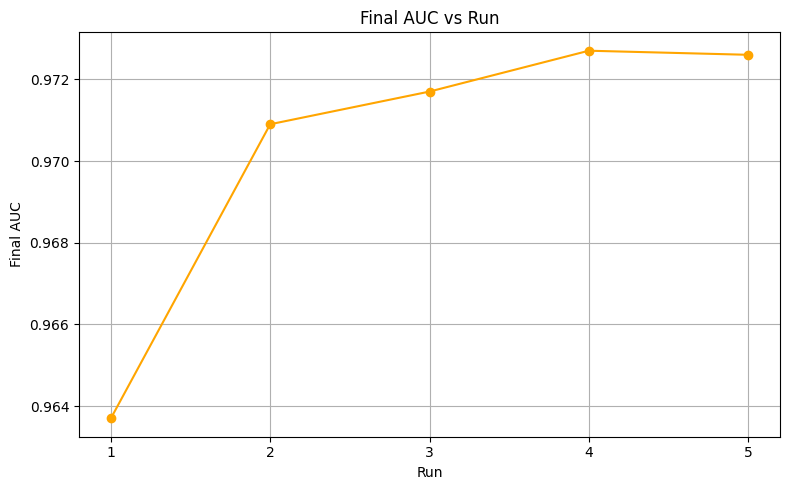

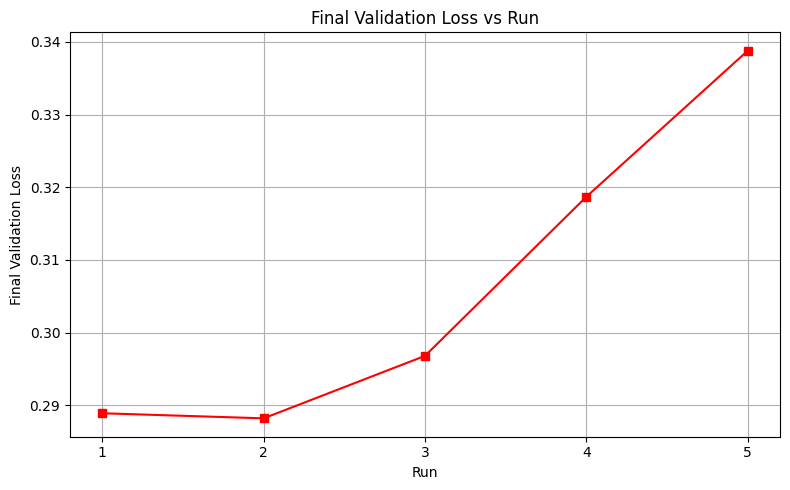

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the experimental results
data = {
    "Run": [1, 2, 3, 4, 5],
    "r": [1, 4, 8, 4, 2],
    "lora_alpha": [1, 16, 32, 8, 4],
    "Final AUC": [0.9637, 0.9709, 0.9717, 0.9727, 0.9726],
    "Final Val Loss": [0.2889, 0.2882, 0.2968, 0.3187, 0.3388]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df)

# Plot: Final AUC vs Run
plt.figure(figsize=(8, 5))
plt.plot(df["Run"], df["Final AUC"], marker='o', color='orange')
plt.title("Final AUC vs Run")
plt.xlabel("Run")
plt.ylabel("Final AUC")
plt.grid(True)
plt.xticks(df["Run"])
plt.tight_layout()
plt.show()

# Plot: Final Validation Loss vs Run
plt.figure(figsize=(8, 5))
plt.plot(df["Run"], df["Final Val Loss"], marker='s', color='red')
plt.title("Final Validation Loss vs Run")
plt.xlabel("Run")
plt.ylabel("Final Validation Loss")
plt.grid(True)
plt.xticks(df["Run"])
plt.tight_layout()
plt.show()

The two graphs provide visual support for the observed trends in model performance across different LoRA configurations. The first graph, Final AUC vs Run, shows that increasing the LoRA rank (r) and scaling factor (lora_alpha) generally led to higher AUC values. This trend confirms that more expressive LoRA setups can improve task-specific adaptation, with AUC rising from 0.9637 in the baseline (Run 1) to a peak of 0.9727 in Run 4. However, the curve begins to flatten after Run 3, indicating diminishing returns—larger values continue to boost AUC, but the marginal gains become smaller. The second graph, Final Validation Loss vs Run, reveals a tradeoff: while AUC increases, validation loss also rises in later runs, particularly in Runs 4 and 5. This suggests that very large LoRA configurations may lead to overfitting or instability. The lowest validation losses appear in Runs 1 and 2, which aligns with better generalization despite slightly lower AUC scores. Taken together, these graphs confirm that moderate configurations such as r=4 and lora_alpha=16 offer the best balance between performance and training stability.